# Apple Stock Price Analysis & Prediction
### End-to-end analysis using the OSEMN framework
---
**Author:** Michał Mańkowski
**Stock:** Apple Inc. (AAPL)
**Stack:** Python, yfinance, Pandas, Scikit-learn, Matplotlib

##  O — Obtain
### Downloading Apple stock data via yfinance API

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

# Download Apple stock data (20 years)
ticker = yf.Ticker("AAPL")
df = ticker.history(period="20y")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Shape: (5031, 7)

First 5 rows:


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2006-05-18 00:00:00-04:00,1.966158,1.983522,1.889524,1.891320,658442400,0.0,0.0
2006-05-19 00:00:00-04:00,1.893715,1.942211,1.880543,1.931135,985866000,0.0,0.0
2006-05-22 00:00:00-04:00,1.911975,1.915568,1.879047,1.897307,718975600,0.0,0.0
2006-05-23 00:00:00-04:00,1.941612,1.951490,1.885932,1.890422,694414000,0.0,0.0
2006-05-24 00:00:00-04:00,1.885633,1.905390,1.842825,1.896110,916031200,0.0,0.0


### Dataset Overview
- **20 years** of Apple stock data
- **8 columns:** Open, High, Low, Close, Volume, Dividends, Stock Splits, Capital Gains
- Data sourced directly from Yahoo Finance API

## S — Scrub
### Checking data quality and cleaning

In [4]:
print("Column types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nBasic statistics:")
df.describe()

Column types:
Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
Dividends       float64
Stock Splits    float64
dtype: object

Missing values:
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

Basic statistics:


,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,5031.000000,5031.000000,5031.000000,5031.000000,5.031000e+03,5031.000000,5031.000000
mean,67.468922,68.196680,66.787175,67.522437,3.348765e+08,0.002047,0.002186
std,77.584614,78.419091,76.828147,77.660766,3.679462e+08,0.020114,0.113656
min,1.548560,1.583285,1.501561,1.516828,1.791060e+07,0.000000,0.000000
25%,10.422469,10.484434,10.352719,10.427707,8.489835e+07,0.000000,0.000000
50%,26.544087,26.758703,26.309683,26.619013,1.722536e+08,0.000000,0.000000
75%,128.783839,130.462244,127.236585,128.513252,4.664450e+08,0.000000,0.000000
max,300.239990,303.200012,296.519989,300.230011,3.372970e+09,0.270000,7.000000


### Scrub Observations
- **0 missing values** — clean dataset, no imputation needed
- Data ready for exploration

## E — Explore
### Exploratory Data Analysis — price trends, volume and returns

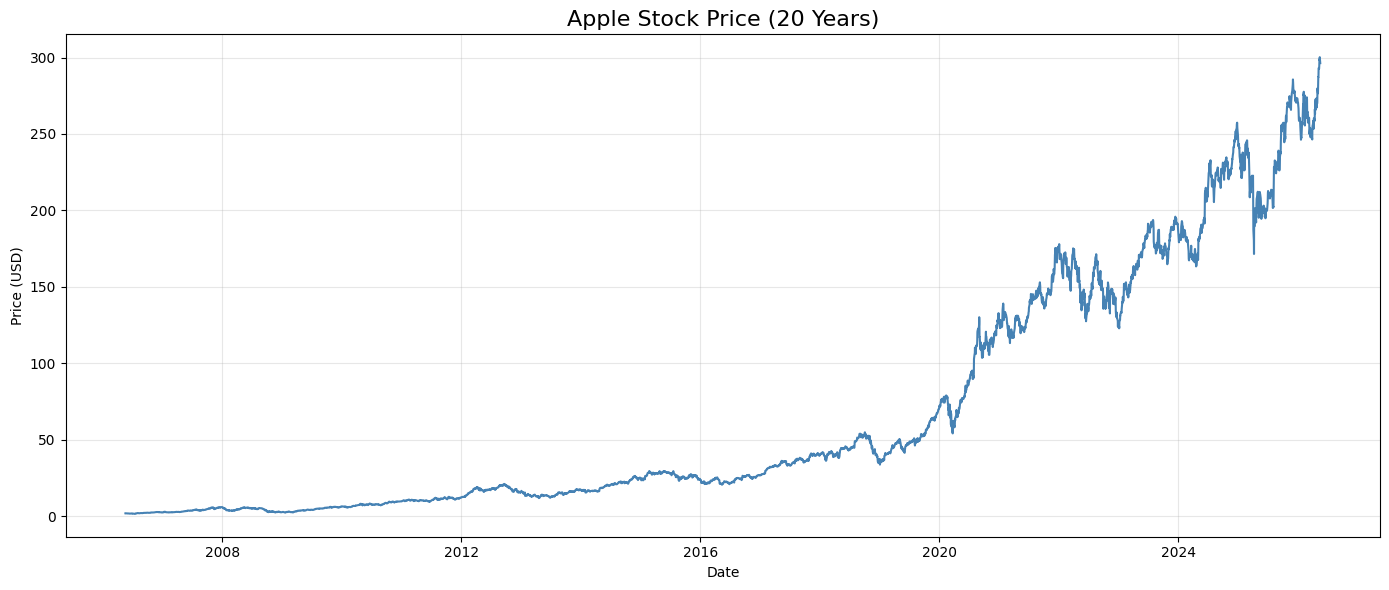

In [5]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], color='steelblue', linewidth=1.5)
plt.title('Apple Stock Price (20 Years)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### EDA Observations
- Clear **long-term upward trend** over 20 years
- Visible **cyclical dips** — likely correlated with market crashes (2008, COVID 2020, rate hikes 2022)
- Significant price acceleration **post-2020** — driven by COVID digital boom

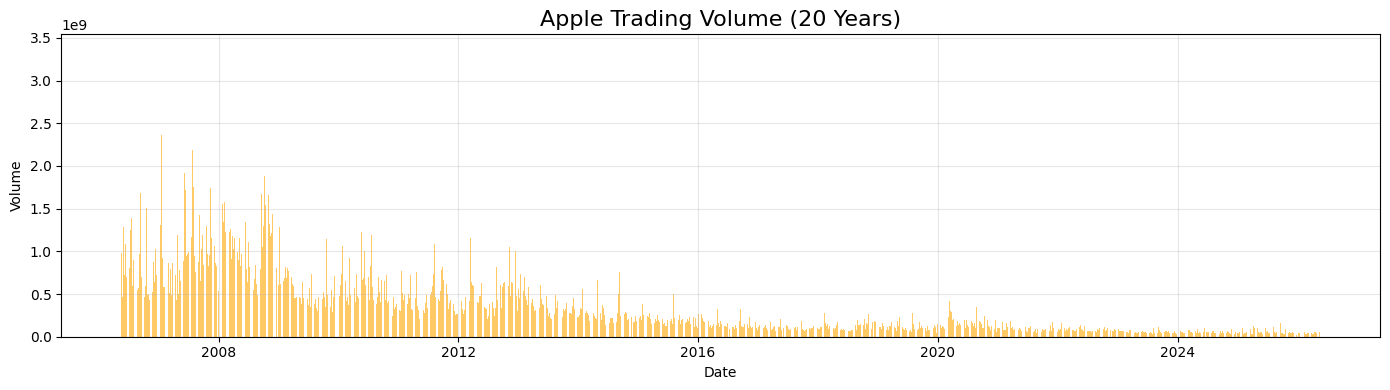

In [8]:
plt.figure(figsize=(14, 4))
plt.bar(df.index, df['Volume'], color='orange', alpha=0.6, width=1)
plt.title('Apple Trading Volume (20 Years)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- Highest trading volume observed **2006-2009** — likely driven by 2008 financial crisis volatility
- Lower but stable volume in recent years despite much higher price levels

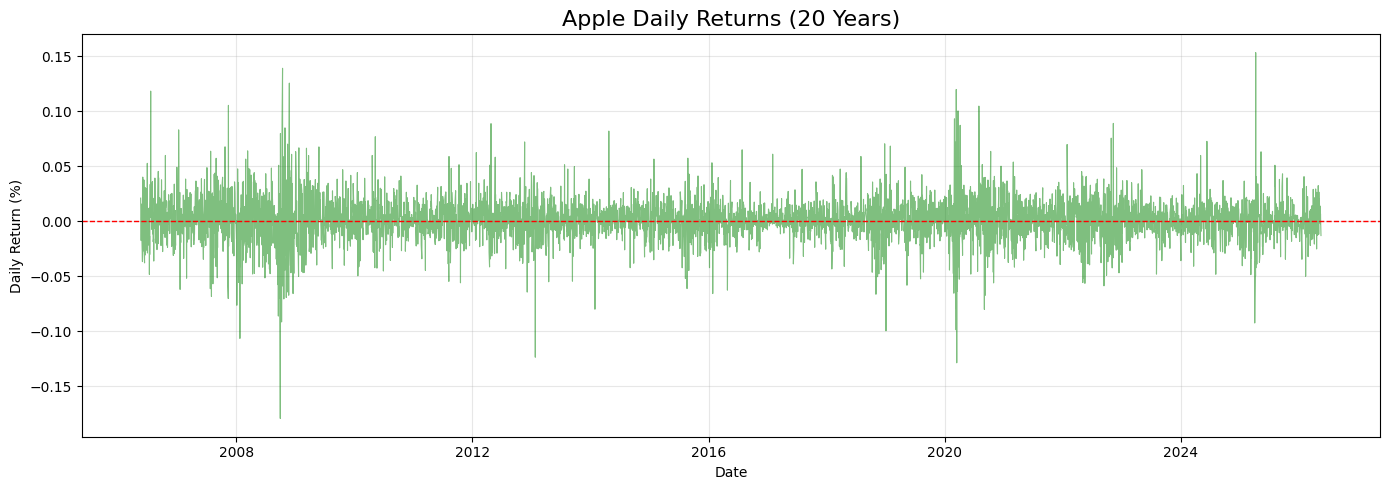

Average daily return: 0.0012
Max daily return: 0.1533
Min daily return: -0.1792
Volatility (std): 0.0198


In [9]:
# Calculate daily returns
df['Daily_Return'] = df['Close'].pct_change()

plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Daily_Return'], color='green', alpha=0.5, linewidth=0.8)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.title('Apple Daily Returns (20 Years)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Daily Return (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Average daily return: {df['Daily_Return'].mean():.4f}")
print(f"Max daily return: {df['Daily_Return'].max():.4f}")
print(f"Min daily return: {df['Daily_Return'].min():.4f}")
print(f"Volatility (std): {df['Daily_Return'].std():.4f}")

- Average daily return: **+0.12%** — strong long-term growth
- Max single day gain: **+15.33%** — likely post earnings report
- Max single day loss: **-17.92%** — likely market crash event
- Daily volatility: **1.79%** — moderate price swings

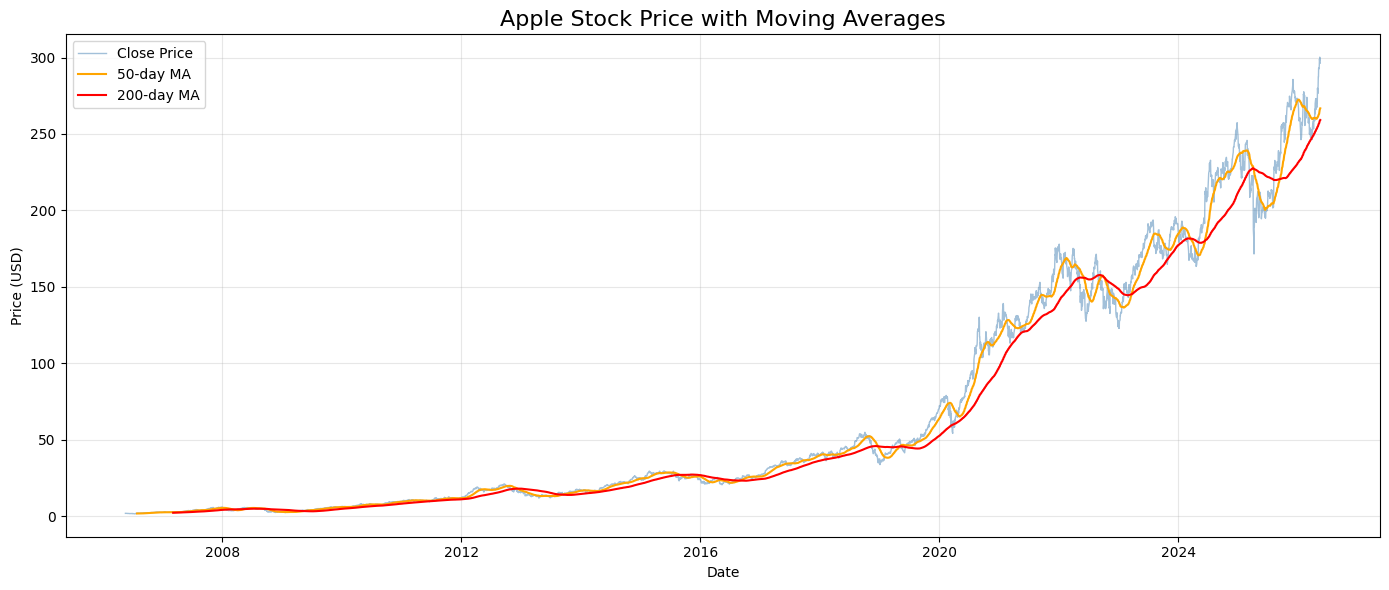

In [10]:
# Moving averages
df['MA_50'] = df['Close'].rolling(window=50).mean()
df['MA_200'] = df['Close'].rolling(window=200).mean()

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], color='steelblue', alpha=0.5, linewidth=1, label='Close Price')
plt.plot(df.index, df['MA_50'], color='orange', linewidth=1.5, label='50-day MA')
plt.plot(df.index, df['MA_200'], color='red', linewidth=1.5, label='200-day MA')
plt.title('Apple Stock Price with Moving Averages', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##  M — Model
### Predicting Apple stock price using Machine Learning

We will predict the next day's closing price based on historical data.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Feature engineering
df['Target'] = df['Close'].shift(-1)  # next day price

df['Return_5d'] = df['Close'].pct_change(5)   # 5 day return
df['Return_20d'] = df['Close'].pct_change(20) # 20 day return
df['MA_50'] = df['Close'].rolling(50).mean()
df['MA_200'] = df['Close'].rolling(200).mean()
df['Volatility'] = df['Daily_Return'].rolling(20).std()

# Drop NaN rows created by rolling windows
df_model = df.dropna()

# Features and target
features = ['Close', 'Volume', 'MA_50', 'MA_200',
            'Return_5d', 'Return_20d', 'Volatility']

X = df_model[features]
y = df_model['Target']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (4831, 7)
Target shape: (4831,)


In [14]:
# Split data - time series so NO shuffle!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

# Model 1 - Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# Model 2 - Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# Results
print("\n=== Linear Regression ===")
print(f"MAE: ${mean_absolute_error(y_test, lr_pred):.2f}")
print(f"R²: {r2_score(y_test, lr_pred):.4f}")

print("\n=== Random Forest ===")
print(f"MAE: ${mean_absolute_error(y_test, rf_pred):.2f}")
print(f"R²: {r2_score(y_test, rf_pred):.4f}")

Training set: (3864, 7)
Test set: (967, 7)

=== Linear Regression ===
MAE: $2.31
R²: 0.9935

=== Random Forest ===
MAE: $36.67
R²: -0.5009


In [15]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

# Model 3 - Gradient Boosting
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

# Model 4 - KNN
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)

# Results
print("=== Gradient Boosting ===")
print(f"MAE: ${mean_absolute_error(y_test, gb_pred):.2f}")
print(f"R²: {r2_score(y_test, gb_pred):.4f}")

print("\n=== KNN ===")
print(f"MAE: ${mean_absolute_error(y_test, knn_pred):.2f}")
print(f"R²: {r2_score(y_test, knn_pred):.4f}")

=== Gradient Boosting ===
MAE: $38.73
R²: -0.6295

=== KNN ===
MAE: $109.32
R²: -7.2327


### Key Finding
Linear Regression outperforms all complex models because stock prices
follow a near-perfect linear pattern: tomorrow's price ≈ today's price.
Complex models like Random Forest and KNN overfit to noise rather than
learning the underlying trend.

##  N — Interpret
### Results visualization and key findings

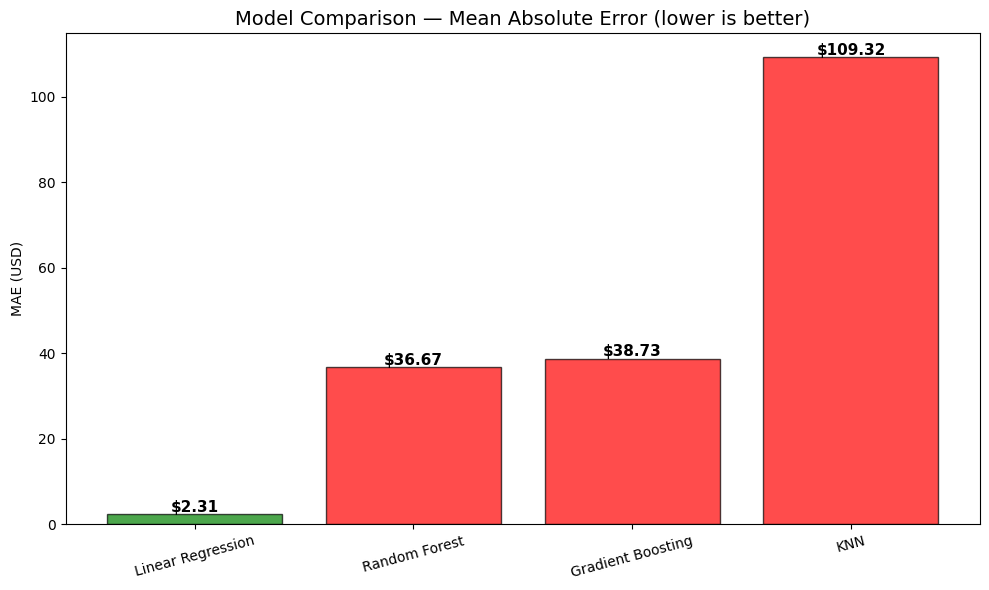

In [16]:
models = ['Linear Regression', 'Random Forest', 'Gradient Boosting', 'KNN']
mae_scores = [
    mean_absolute_error(y_test, lr_pred),
    mean_absolute_error(y_test, rf_pred),
    mean_absolute_error(y_test, gb_pred),
    mean_absolute_error(y_test, knn_pred)
]

plt.figure(figsize=(10, 6))
colors = ['green', 'red', 'red', 'red']
bars = plt.bar(models, mae_scores, color=colors, alpha=0.7, edgecolor='black')
plt.title('Model Comparison — Mean Absolute Error (lower is better)', fontsize=14)
plt.ylabel('MAE (USD)')
plt.xticks(rotation=15)

# Add values on bars
for bar, score in zip(bars, mae_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'${score:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

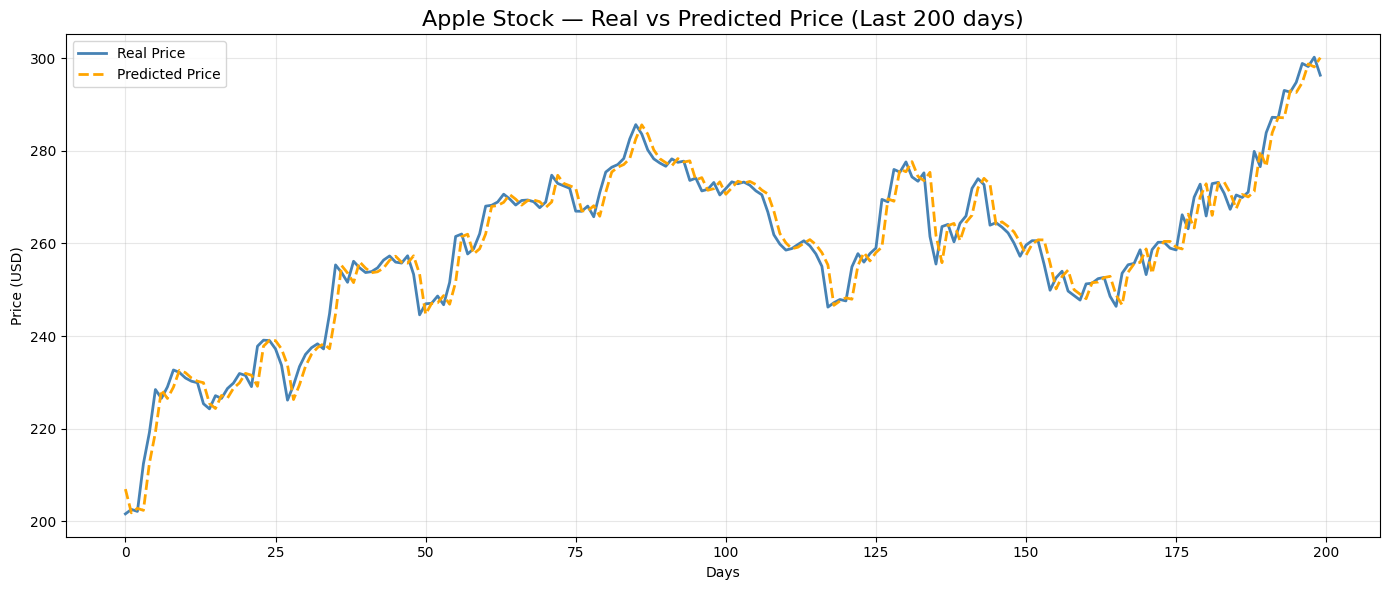

In [17]:
plt.figure(figsize=(14, 6))
plt.plot(y_test.values[-200:], color='steelblue', label='Real Price', linewidth=2)
plt.plot(lr_pred[-200:], color='orange', linestyle='--', label='Predicted Price', linewidth=2)
plt.title('Apple Stock — Real vs Predicted Price (Last 200 days)', fontsize=16)
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##  Conclusions

### Key Findings:
- Apple stock shows a clear **long-term upward trend** over 20 years
- Highest volatility observed during **2008 financial crisis**
- Average daily return: **+0.12%** — strong consistent growth
- **Linear Regression** outperforms all complex models (MAE: $2.31, R²: 0.99)

### Why Linear Regression wins:
Tomorrow's stock price ≈ today's price + small change.
This near-perfect linear relationship makes simple models superior
to complex ones like Random Forest or KNN which overfit to noise.

### Business Insight:
Apple stock has been one of the most predictable and consistently
growing assets over the past 20 years — making it an excellent
long-term investment.